Running on: cuda

Generating planning datasets...
Training samples: 1200
Small test samples: 300
Large unseen test samples: 300

Model initialized.
PlanSketchGNN(
  (gcn1): GCNLayer(
    (linear): Linear(in_features=6, out_features=64, bias=True)
  )
  (gcn2): GCNLayer(
    (linear): Linear(in_features=64, out_features=64, bias=True)
  )
  (gcn3): GCNLayer(
    (linear): Linear(in_features=64, out_features=64, bias=True)
  )
  (policy_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)

Training PlanSketch-GNN...
Epoch 01 | Loss: 1.3312 | Train Accuracy: 0.3600
Epoch 02 | Loss: 1.2951 | Train Accuracy: 0.3942
Epoch 03 | Loss: 1.2104 | Train Accuracy: 0.5483
Epoch 04 | Loss: 1.1439 | Train Accuracy: 0.5500
Epoch 05 | Loss: 1.0812 | Train Accuracy: 0.5842
Epoch 06 | Loss: 1.0327 | Train Accuracy: 0.6025
Epoch 07 | Loss: 0.9766 | Train Accuracy: 0.6333
Epoch 08 | Loss: 0.9377 | Tra

,Evaluation Setting,Grid Sizes,Metric,Value
0,Small seen-size grids,"4, 5, 6",Action Prediction Accuracy,71.67
1,Larger unseen grids,"7, 8, 9",Action Prediction Accuracy,66.33
2,Generalization,Train small → Test large,Generalization Gap,5.33



Evaluating policy rollout success on unseen larger grids...


Rollout 8x8: 100%|██████████| 50/50 [00:00<00:00, 95.24it/s]


Rollout Evaluation:


,Grid Size,Success Rate (%),Average Successful Path Length
0,7x7,20.0,3.60
1,8x8,16.0,3.12



Visualizing one learned policy rollout...


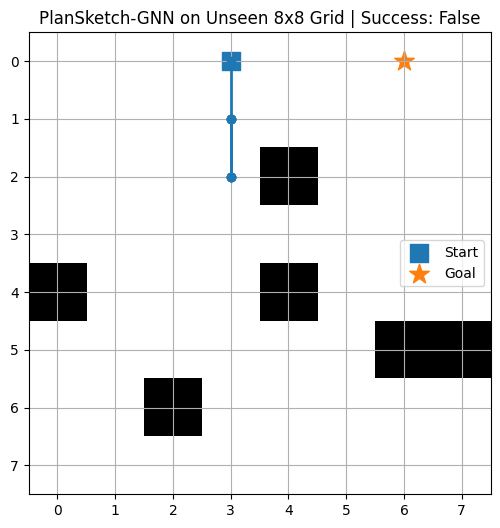

Demo Start: (0, 3)
Demo Goal: (0, 6)
Demo Success: False
Demo Path: [(0, 3), (1, 3), (2, 3), (1, 3), (2, 3), (1, 3), (2, 3), (1, 3), (2, 3)]

Saved output files:
/content/plansketch_gnn_training_history.csv
/content/plansketch_gnn_evaluation_summary.csv
/content/plansketch_gnn_rollout_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# PlanSketch-GNN: Learning Generalizable Planning Policies
# Google Colab Free Version - One Cell Implementation
#
# Idea:
# Learn a reusable planning policy using a Graph Neural Network.
# Domain: Grid Navigation Planning
# Training: small grids
# Testing: larger unseen grids
#
# Dataset:
# 1. Benchmark reference: https://github.com/potassco/pddl-instances
# 2. This notebook generates a simple Grid Navigation planning dataset automatically.
# ============================================================

# -----------------------------
# 0. Install dependencies
# -----------------------------
!pip install -q torch networkx pandas matplotlib scikit-learn tqdm

import random
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1. Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)

# -----------------------------
# 2. Problem Setting
# -----------------------------
# Actions:
# 0 = UP
# 1 = DOWN
# 2 = LEFT
# 3 = RIGHT

ACTION_NAMES = {
    0: "UP",
    1: "DOWN",
    2: "LEFT",
    3: "RIGHT"
}

# -----------------------------
# 3. Grid Navigation Environment
# -----------------------------
def generate_grid_instance(grid_size=5, obstacle_prob=0.15):
    """
    Creates a grid planning instance.
    Start and goal are randomly chosen free cells.
    Obstacles are randomly placed.
    """
    grid = np.zeros((grid_size, grid_size), dtype=int)

    for r in range(grid_size):
        for c in range(grid_size):
            if random.random() < obstacle_prob:
                grid[r, c] = 1  # obstacle

    free_cells = [(r, c) for r in range(grid_size) for c in range(grid_size) if grid[r, c] == 0]

    if len(free_cells) < 2:
        return generate_grid_instance(grid_size, obstacle_prob)

    start = random.choice(free_cells)
    goal = random.choice(free_cells)

    while goal == start:
        goal = random.choice(free_cells)

    return grid, start, goal


def valid_neighbors(grid, cell):
    """
    Returns valid neighboring cells and corresponding action labels.
    """
    r, c = cell
    grid_size = grid.shape[0]

    moves = [
        (-1, 0, 0),  # UP
        (1, 0, 1),   # DOWN
        (0, -1, 2),  # LEFT
        (0, 1, 3)    # RIGHT
    ]

    neighbors = []

    for dr, dc, action in moves:
        nr, nc = r + dr, c + dc
        if 0 <= nr < grid_size and 0 <= nc < grid_size and grid[nr, nc] == 0:
            neighbors.append(((nr, nc), action))

    return neighbors


def shortest_path_action(grid, start, goal):
    """
    Uses BFS to find the first optimal action from start toward goal.
    Returns None if no path exists.
    """
    queue = [(start, [])]
    visited = set([start])

    while queue:
        current, path = queue.pop(0)

        if current == goal:
            if len(path) == 0:
                return None
            return path[0]

        for nxt, action in valid_neighbors(grid, current):
            if nxt not in visited:
                visited.add(nxt)
                queue.append((nxt, path + [action]))

    return None


# -----------------------------
# 4. Convert Planning State to Graph
# -----------------------------
def state_to_graph_features(grid, agent_pos, goal_pos):
    """
    Converts a planning state into graph features.

    Each grid cell is a node.
    Node features:
    [is_obstacle, is_agent, is_goal, row_norm, col_norm, manhattan_to_goal_norm]
    """
    grid_size = grid.shape[0]
    num_nodes = grid_size * grid_size

    node_features = []
    adjacency = np.zeros((num_nodes, num_nodes), dtype=np.float32)

    def node_id(r, c):
        return r * grid_size + c

    for r in range(grid_size):
        for c in range(grid_size):
            is_obstacle = 1.0 if grid[r, c] == 1 else 0.0
            is_agent = 1.0 if (r, c) == agent_pos else 0.0
            is_goal = 1.0 if (r, c) == goal_pos else 0.0
            row_norm = r / max(1, grid_size - 1)
            col_norm = c / max(1, grid_size - 1)
            manhattan = abs(r - goal_pos[0]) + abs(c - goal_pos[1])
            manhattan_norm = manhattan / (2 * max(1, grid_size - 1))

            node_features.append([
                is_obstacle,
                is_agent,
                is_goal,
                row_norm,
                col_norm,
                manhattan_norm
            ])

    for r in range(grid_size):
        for c in range(grid_size):
            if grid[r, c] == 1:
                continue

            current_id = node_id(r, c)

            for (nr, nc), _ in valid_neighbors(grid, (r, c)):
                neighbor_id = node_id(nr, nc)
                adjacency[current_id, neighbor_id] = 1.0

    # Add self-loops
    adjacency = adjacency + np.eye(num_nodes, dtype=np.float32)

    # Normalize adjacency
    degree = np.sum(adjacency, axis=1)
    degree_inv_sqrt = np.power(degree, -0.5)
    degree_inv_sqrt[np.isinf(degree_inv_sqrt)] = 0.0
    D_inv_sqrt = np.diag(degree_inv_sqrt)
    adjacency_norm = D_inv_sqrt @ adjacency @ D_inv_sqrt

    return np.array(node_features, dtype=np.float32), adjacency_norm.astype(np.float32)


# -----------------------------
# 5. Generate Dataset
# -----------------------------
def generate_dataset(num_samples=1000, grid_sizes=[5, 6], obstacle_prob=0.15):
    """
    Generates supervised planning data.
    Label = first optimal action from current state to goal.
    """
    data = []

    attempts = 0
    max_attempts = num_samples * 20

    while len(data) < num_samples and attempts < max_attempts:
        attempts += 1

        grid_size = random.choice(grid_sizes)
        grid, start, goal = generate_grid_instance(grid_size, obstacle_prob)

        action = shortest_path_action(grid, start, goal)

        if action is None:
            continue

        x, adj = state_to_graph_features(grid, start, goal)

        data.append({
            "x": x,
            "adj": adj,
            "label": action,
            "grid_size": grid_size,
            "grid": grid,
            "start": start,
            "goal": goal
        })

    return data


print("\nGenerating planning datasets...")

train_data = generate_dataset(
    num_samples=1200,
    grid_sizes=[4, 5, 6],
    obstacle_prob=0.15
)

test_small_data = generate_dataset(
    num_samples=300,
    grid_sizes=[4, 5, 6],
    obstacle_prob=0.15
)

test_large_data = generate_dataset(
    num_samples=300,
    grid_sizes=[7, 8, 9],
    obstacle_prob=0.15
)

print("Training samples:", len(train_data))
print("Small test samples:", len(test_small_data))
print("Large unseen test samples:", len(test_large_data))


# -----------------------------
# 6. Batch Padding
# -----------------------------
def collate_batch(batch):
    """
    Pads graphs to the maximum number of nodes in the batch.
    """
    max_nodes = max(item["x"].shape[0] for item in batch)
    feature_dim = batch[0]["x"].shape[1]

    xs = []
    adjs = []
    masks = []
    labels = []

    for item in batch:
        x = item["x"]
        adj = item["adj"]
        n = x.shape[0]

        x_pad = np.zeros((max_nodes, feature_dim), dtype=np.float32)
        adj_pad = np.zeros((max_nodes, max_nodes), dtype=np.float32)
        mask = np.zeros(max_nodes, dtype=np.float32)

        x_pad[:n, :] = x
        adj_pad[:n, :n] = adj
        mask[:n] = 1.0

        xs.append(x_pad)
        adjs.append(adj_pad)
        masks.append(mask)
        labels.append(item["label"])

    xs = torch.tensor(np.stack(xs), dtype=torch.float32).to(DEVICE)
    adjs = torch.tensor(np.stack(adjs), dtype=torch.float32).to(DEVICE)
    masks = torch.tensor(np.stack(masks), dtype=torch.float32).to(DEVICE)
    labels = torch.tensor(labels, dtype=torch.long).to(DEVICE)

    return xs, adjs, masks, labels


def make_batches(data, batch_size=32, shuffle=True):
    if shuffle:
        random.shuffle(data)

    for i in range(0, len(data), batch_size):
        yield collate_batch(data[i:i + batch_size])


# -----------------------------
# 7. GNN Model
# -----------------------------
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, adj):
        h = torch.bmm(adj, x)
        h = self.linear(h)
        return F.relu(h)


class PlanSketchGNN(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, num_actions=4):
        super().__init__()

        self.gcn1 = GCNLayer(input_dim, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, hidden_dim)
        self.gcn3 = GCNLayer(hidden_dim, hidden_dim)

        self.policy_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions)
        )

    def forward(self, x, adj, mask):
        h = self.gcn1(x, adj)
        h = self.gcn2(h, adj)
        h = self.gcn3(h, adj)

        # Agent node embedding
        # Feature index 1 is is_agent
        agent_indicator = x[:, :, 1].unsqueeze(-1)
        agent_embedding = torch.sum(h * agent_indicator, dim=1)

        # Global graph embedding
        mask_expanded = mask.unsqueeze(-1)
        graph_embedding = torch.sum(h * mask_expanded, dim=1) / torch.clamp(mask_expanded.sum(dim=1), min=1.0)

        combined = torch.cat([agent_embedding, graph_embedding], dim=1)

        logits = self.policy_head(combined)
        return logits


model = PlanSketchGNN(input_dim=6, hidden_dim=64, num_actions=4).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

print("\nModel initialized.")
print(model)


# -----------------------------
# 8. Training
# -----------------------------
def train_model(model, train_data, epochs=20, batch_size=32):
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        all_preds = []
        all_labels = []

        for xs, adjs, masks, labels in make_batches(train_data, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()

            logits = model(xs, adjs, masks)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        avg_loss = total_loss / max(1, math.ceil(len(train_data) / batch_size))

        history.append({
            "epoch": epoch,
            "loss": avg_loss,
            "train_accuracy": acc
        })

        print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Train Accuracy: {acc:.4f}")

    return pd.DataFrame(history)


print("\nTraining PlanSketch-GNN...")
history_df = train_model(
    model,
    train_data,
    epochs=20,
    batch_size=32
)


# -----------------------------
# 9. Evaluation
# -----------------------------
def evaluate_model(model, data, batch_size=64, name="Test"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xs, adjs, masks, labels in make_batches(data, batch_size=batch_size, shuffle=False):
            logits = model(xs, adjs, masks)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=["UP", "DOWN", "LEFT", "RIGHT"],
        digits=4
    ))

    return acc, all_labels, all_preds


small_acc, small_labels, small_preds = evaluate_model(
    model,
    test_small_data,
    name="In-Distribution Small Grid Test"
)

large_acc, large_labels, large_preds = evaluate_model(
    model,
    test_large_data,
    name="Out-of-Distribution Larger Grid Test"
)

generalization_gap = small_acc - large_acc

summary_df = pd.DataFrame([
    {
        "Evaluation Setting": "Small seen-size grids",
        "Grid Sizes": "4, 5, 6",
        "Metric": "Action Prediction Accuracy",
        "Value": round(small_acc * 100, 2)
    },
    {
        "Evaluation Setting": "Larger unseen grids",
        "Grid Sizes": "7, 8, 9",
        "Metric": "Action Prediction Accuracy",
        "Value": round(large_acc * 100, 2)
    },
    {
        "Evaluation Setting": "Generalization",
        "Grid Sizes": "Train small → Test large",
        "Metric": "Generalization Gap",
        "Value": round(generalization_gap * 100, 2)
    }
])

print("\nFinal Evaluation Summary:")
display(summary_df)


# -----------------------------
# 10. Rollout Evaluation
# -----------------------------
def rollout_policy(model, grid, start, goal, max_steps=50):
    """
    Runs the learned policy in the environment.
    Success = reaches goal within max_steps.
    """
    current = start
    path = [current]

    for step in range(max_steps):
        if current == goal:
            return True, path

        x, adj = state_to_graph_features(grid, current, goal)
        batch = [{
            "x": x,
            "adj": adj,
            "label": 0,
            "grid_size": grid.shape[0],
            "grid": grid,
            "start": current,
            "goal": goal
        }]

        xs, adjs, masks, _ = collate_batch(batch)

        model.eval()
        with torch.no_grad():
            logits = model(xs, adjs, masks)
            action = int(torch.argmax(logits, dim=1).detach().cpu().numpy()[0])

        r, c = current

        if action == 0:
            nxt = (r - 1, c)
        elif action == 1:
            nxt = (r + 1, c)
        elif action == 2:
            nxt = (r, c - 1)
        else:
            nxt = (r, c + 1)

        # Invalid move = stay
        if (
            nxt[0] < 0 or nxt[0] >= grid.shape[0] or
            nxt[1] < 0 or nxt[1] >= grid.shape[1] or
            grid[nxt[0], nxt[1]] == 1
        ):
            nxt = current

        current = nxt
        path.append(current)

        # Prevent endless stuck loop
        if len(path) > 8 and len(set(path[-6:])) <= 2:
            return False, path

    return current == goal, path


def evaluate_rollout_success(model, num_instances=100, grid_size=8, obstacle_prob=0.15):
    successes = 0
    path_lengths = []

    for _ in tqdm(range(num_instances), desc=f"Rollout {grid_size}x{grid_size}"):
        grid, start, goal = generate_grid_instance(grid_size, obstacle_prob)

        optimal_action = shortest_path_action(grid, start, goal)
        if optimal_action is None:
            continue

        success, path = rollout_policy(model, grid, start, goal, max_steps=grid_size * grid_size)

        if success:
            successes += 1
            path_lengths.append(len(path) - 1)

    success_rate = successes / num_instances
    avg_path_length = np.mean(path_lengths) if path_lengths else None

    return success_rate, avg_path_length


print("\nEvaluating policy rollout success on unseen larger grids...")

success_7, path_7 = evaluate_rollout_success(model, num_instances=50, grid_size=7)
success_8, path_8 = evaluate_rollout_success(model, num_instances=50, grid_size=8)

rollout_df = pd.DataFrame([
    {
        "Grid Size": "7x7",
        "Success Rate (%)": round(success_7 * 100, 2),
        "Average Successful Path Length": round(path_7, 2) if path_7 is not None else "N/A"
    },
    {
        "Grid Size": "8x8",
        "Success Rate (%)": round(success_8 * 100, 2),
        "Average Successful Path Length": round(path_8, 2) if path_8 is not None else "N/A"
    }
])

print("\nRollout Evaluation:")
display(rollout_df)


# -----------------------------
# 11. Visualization
# -----------------------------
def plot_grid_with_policy(model, grid, start, goal, title="Learned Planning Policy"):
    """
    Visualizes one grid and the path generated by the learned policy.
    """
    success, path = rollout_policy(model, grid, start, goal, max_steps=grid.shape[0] * grid.shape[0])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(grid, cmap="Greys")

    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            ax.text(c, r, "", ha="center", va="center")

    path_rows = [p[0] for p in path]
    path_cols = [p[1] for p in path]

    ax.plot(path_cols, path_rows, marker="o", linewidth=2)
    ax.scatter(start[1], start[0], marker="s", s=160, label="Start")
    ax.scatter(goal[1], goal[0], marker="*", s=220, label="Goal")

    ax.set_xticks(range(grid.shape[1]))
    ax.set_yticks(range(grid.shape[0]))
    ax.grid(True)
    ax.set_title(f"{title} | Success: {success}")
    ax.legend()
    plt.show()

    return success, path


print("\nVisualizing one learned policy rollout...")
demo_grid, demo_start, demo_goal = generate_grid_instance(grid_size=8, obstacle_prob=0.15)

while shortest_path_action(demo_grid, demo_start, demo_goal) is None:
    demo_grid, demo_start, demo_goal = generate_grid_instance(grid_size=8, obstacle_prob=0.15)

demo_success, demo_path = plot_grid_with_policy(
    model,
    demo_grid,
    demo_start,
    demo_goal,
    title="PlanSketch-GNN on Unseen 8x8 Grid"
)

print("Demo Start:", demo_start)
print("Demo Goal:", demo_goal)
print("Demo Success:", demo_success)
print("Demo Path:", demo_path)


# -----------------------------
# 12. Save Results
# -----------------------------
history_path = "/content/plansketch_gnn_training_history.csv"
summary_path = "/content/plansketch_gnn_evaluation_summary.csv"
rollout_path = "/content/plansketch_gnn_rollout_results.csv"

history_df.to_csv(history_path, index=False)
summary_df.to_csv(summary_path, index=False)
rollout_df.to_csv(rollout_path, index=False)

print("\nSaved output files:")
print(history_path)
print(summary_path)
print(rollout_path)

try:
    from google.colab import files
    files.download(history_path)
    files.download(summary_path)
    files.download(rollout_path)
except Exception:
    print("Download skipped. Open files from the Colab file panel.")